★実行環境の選択

In [1]:
# VSCodeの場合
edi_flg = 1
# Googlre Colabの場合
# edi_flg = 0

In [2]:
if edi_flg == 0:
  # GoogleColabにGitHubリポジトリをクローンする用
  %cd /content/My_Python_project

  from google.colab import auth
  auth.authenticate_user()
  !git clone https://github.com/keiseki-eng/My_Python_project
  !git pull origin main



In [3]:
# import sys
# !{sys.executable} -m pip install ipykernel

In [ ]:
if edi_flg == 0:
    !pip install japanize-matplotlib

import os
import sys
import yaml
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split
import shap
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
import japanize_matplotlib #日本語表示対応
from sklearn.model_selection import KFold


# Notebook から src ディレクトリを追加
# sys.path.append(os.path.join(os.getcwd(), "src"))
sys.path.append("/home/keiseki/My_Python_project/src")

In [ ]:
if edi_flg == 0:
  from google.colab import drive
  drive.mount('/content/drive')

In [ ]:
import warnings
warnings.filterwarnings(
    "ignore",
    category=pd.errors.PerformanceWarning
)

## 01.config読み込み

In [ ]:
# VSCode用
if edi_flg==1:
  conf_path = os.path.join( '../../00.config/config.yaml')
  with open(conf_path, 'r') as f:
    config = yaml.safe_load(f)

# GoogleColab用
elif edi_flg==0:
  conf_path = "My_Python_project/config/config.yaml"
  with open(conf_path, "r") as f:
    config = yaml.safe_load(f)

ParserError: while parsing a block mapping
  in "../00.config/config.yaml", line 34, column 5
expected <block end>, but found ','
  in "../00.config/config.yaml", line 34, column 30

In [ ]:
# 定義した特徴量リストを読み込み
feature_list = config['FEATURE']['FEATURE_LIST']

In [ ]:
# カテゴリカルカラムのリストを定義
categorical_cols = config['FEATURE']['CATEGORICAL_COLS']

## 02.データ読み込み

In [ ]:
# VSCode用
if edi_flg==1:
# ドライブ内のファイルパスを指定
    train_path = '../20.Data/train_data_all.pkl'
    df_train = pd.read_pickle(train_path)

# # GoogleColab用
# elif edi_flg==0:
#     # GoogleDriveをマウントしてファイル読み込み準備
#     from google.colab import drive
#     drive.mount('/content/drive')
#     # ドライブ内のファイルパスを指定
#     train_path = '/content/drive/MyDrive/Colab Notebooks/不動産予測/processed_train.pkl'
#     df_train = pd.read_pickle(train_path)

In [ ]:
# testデータの読み込み
# VSCode用
if edi_flg==1:
    test_path = '../20.Data/test.csv'
    df_test = pd.read_csv(test_path, encoding='cp932', index_col=0)

# # GoogleColab用
# elif edi_flg==0:
#     # ドライブ内のファイルパスを指定
#     test_path = '/content/drive/MyDrive/Colab Notebooks/不動産予測/processed_test.pkl'
#     df_test = pd.read_pickle(test_path)

In [ ]:
df_test

,年月日,列車番号
0,2017-01-01,3500E
1,2017-01-01,552E
2,2017-01-01,3502E
3,2017-01-01,9536E
4,2017-01-01,554E
...,...,...
2425,2017-03-31,576E
2426,2017-03-31,3516E
2427,2017-03-31,578E
2428,2017-03-31,3518E


## addr1+2に対し、ターゲットエンコーディングを実装

In [ ]:
# from sklearn.model_selection import KFold
# import numpy as np

# def target_encode_oof(
#     df,
#     col,
#     target,
#     n_splits=5,
#     smoothing=10,
#     random_state=42
# ):
#     df = df.copy()

#     # ★ここが最重要
#     df[target] = df[target].astype(float)
#     global_mean = df[target].mean()

#     kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
#     te_col = np.zeros(len(df))

#     for train_idx, valid_idx in kf.split(df):
#         train_fold = df.iloc[train_idx]
#         valid_fold = df.iloc[valid_idx]

#         stats = (
#             train_fold
#             .groupby(col, observed=True)[target]
#             .agg(["mean", "count"])
#         )

#         stats["smooth"] = (
#             stats["count"] * stats["mean"]
#             + smoothing * global_mean
#         ) / (stats["count"] + smoothing)

#         te_col[valid_idx] = (
#             valid_fold[col]
#             .map(stats["smooth"])
#             .astype(float)          # ← ★ここでカテゴリ解除
#             .fillna(global_mean)
#             .values
#           )


#     df[f"{col}_TE"] = te_col
#     return df, global_mean


In [ ]:
# df_train, addr1_2_global_mean = target_encode_oof(
#     df_train,
#     col="addr1+2",
#     target="money_room",
#     n_splits=5,
#     smoothing=20
# )


In [ ]:
# stats_full = df_train.groupby("addr1+2")["money_room"].agg(["mean", "count"])

# stats_full["smooth"] = (
#     stats_full["count"] * stats_full["mean"]
#     + 20 * addr1_2_global_mean
# ) / (stats_full["count"] + 20)

# # df_test["addr1+2_TE"] = df_test["addr1+2"].map(stats_full["smooth"])
# # df_test["addr1+2_TE"].fillna(addr1_2_global_mean, inplace=True)
# df_test["addr1+2_TE"] = (
#     df_test["addr1+2"]
#     .map(stats_full["smooth"])
#     .astype(float)                 # ← ★最重要
#     .fillna(addr1_2_global_mean)   # ← inplace を使わない
# )



In [ ]:
# # 実際の売買価格で定義し直す
# def make_price_band_by_quantile(price, n_bins=5):
#     return pd.qcut(price, q=n_bins, labels=False)

# df_train["price_band"] = make_price_band_by_quantile(
#     df_train["money_room"],
#     n_bins=5
# )

# def make_sample_weight(price_band):
#     weight_map = {
#         0: 9.0,   # 最低価格帯
#         1: 1.4,
#         2: 1.2,
#         3: 1.2,
#         4: 1.0    # 高価格帯
#     }
#     return price_band.map(weight_map).astype(float)
# df_train["sample_weight"] = make_sample_weight(
#     df_train["price_band"]
# )

## interaction特徴量を追加

In [ ]:
# df_train["unit_area_x_walk_distance1"] = df_train["unit_area"] * df_train["walk_distance1"]
# df_train["unit_area_x_addr_te"]    = df_train["unit_area"] * df_train["addr1+2_TE"]
# df_test["unit_area_x_walk_distance1"] = df_test["unit_area"] * df_test["walk_distance1"]
# df_test["unit_area_x_addr_te"]    = df_train["unit_area"] * df_test["addr1+2_TE"]

In [ ]:
# feature_list = feature_list + ["pseudo_price_band"]
# feature_list = feature_list + ["addr1+2_TE"]
# feature_list = feature_list + ["unit_area_x_walk_distance1"]
# feature_list = feature_list + ["unit_area_x_addr_te"]
# categorical_cols = categorical_cols + ["pseudo_price_band"]


## 05.train/valid 分割　＆　target加工

＿★サンプルウェイトを価格帯別に調整可能とする

In [ ]:
# X_all, X_train, X_validの再構築
X_all = df_train[feature_list]
y_all = df_train["合計"]


# 目的変数が右に裾野が広いので対数変換
# y_all = np.log1p(y_all)


X_train, X_valid, y_train, y_valid, = train_test_split(X_all, y_all, test_size=0.2, random_state=42)

## 06.sample_weight適用

## 07.モデル学習

In [ ]:

def wmae_eval(preds, train_data):
    y_true = train_data.get_label()

    # 重み
    weights = y_true

    # 0以下の値がある場合に備える
    weights = np.maximum(weights, 1e-6)

    wmae = np.sum(weights * np.abs(y_true - preds)) / np.sum(weights)

    return "WMAE", wmae, False

In [ ]:
# LightGBM のパラメータ設定
params = config['MODEL_PARAMS']

# LightGBM のデータセットを作成
lgb_train = lgb.Dataset(
    X_train,
    y_train,
    categorical_feature=categorical_cols
)


lgb_test = lgb.Dataset(
    X_valid,
    y_valid,
    reference=lgb_train,
    categorical_feature=categorical_cols
)

In [ ]:
# 学習データの前処理：object型の列をcategoryへ
cat_cols = [c for c in categorical_cols if c in X_train.columns]
# 明示的にobject型の全列もcategoryに変換（未指定のカテゴリ列がある場合に備えて）
obj_cols = X_train.select_dtypes(include=["object"]).columns.tolist()

for df in [X_train, X_valid, X_all, df_train, df_test]:
    cols = sorted(set(cat_cols + obj_cols).intersection(df.columns))
    if cols:
        df[cols] = df[cols].astype("category")

In [ ]:
# モデルの学習
model = lgb.train(
    params,
    lgb_train,
    num_boost_round=1000,
    valid_sets=[lgb_train, lgb_test],
    feval=wmae_eval,
    callbacks=[
        lgb.early_stopping(100)
    ]
)

Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[284]	training's WMAE: 0.0112028	valid_1's WMAE: 0.00799023


## 08.評価

特徴量の重要度


<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

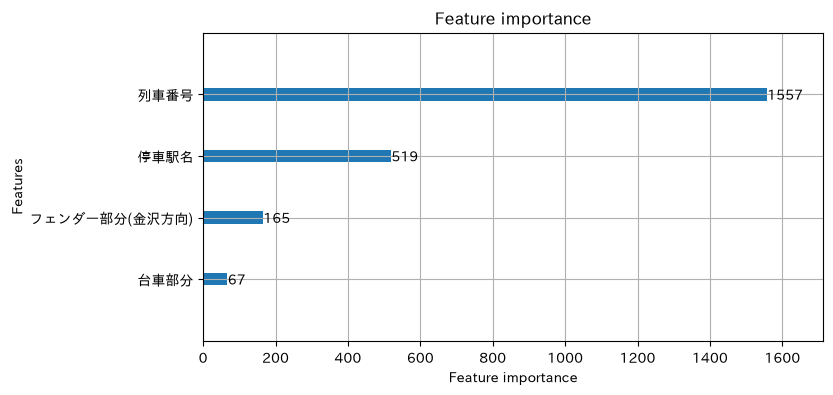

In [ ]:
# テストデータで予測
y_pred = model.predict(X_valid , num_iteration=model.best_iteration)


# 対数変換を戻す
y_pred = np.expm1(y_pred)
y_valid = np.expm1(y_valid)


# 特徴量の重要度
print("特徴量の重要度")
lgb.plot_importance(model, figsize=(8,4))


## 09.可視化（importance SHAP）

In [ ]:

# import lightgbm as lgb
# from sklearn.model_selection import GridSearchCV

# # パラメータの探索範囲を指定
# param_grid = {
#     'num_leaves': [20, 30, 40],
#     'learning_rate': [0.01, 0.1, 0.5],
#     'max_depth': [5, 10]
# }




# # グリッドサーチCV
# gsearch = GridSearchCV(gbm, param_grid, cv=5) #cvは交差検証の回数

# # データを学習
# gsearch.fit(X_train, y_train, eval_set=[(X_valid, y_valid)], callbacks=[lgb.early_stopping(stopping_rounds=100, verbose=False)])



# # 最適なパラメータとスコアを表示
# print('Best parameters found by grid search are:', gsearch.best_params_)
# print('Best score:', gsearch.best_score_)


In [ ]:
# # パラメータの辞書を結合
# best_params = {**params, **gsearch.best_params_}

# # 最適パラメータでモデルを再学習
# model = lgb.LGBMClassifier(**best_params)
# model.fit(X_train, y_train)

In [ ]:
#SHAP値の取得
explainer = shap.TreeExplainer(model=model)#SHAP値を取得するためのモデル作成
shap_values = explainer.shap_values(X=X_valid)#説明変数それぞれの値のSHAP値を取得する

# print(shap_values)
# print(shap_values.shape)


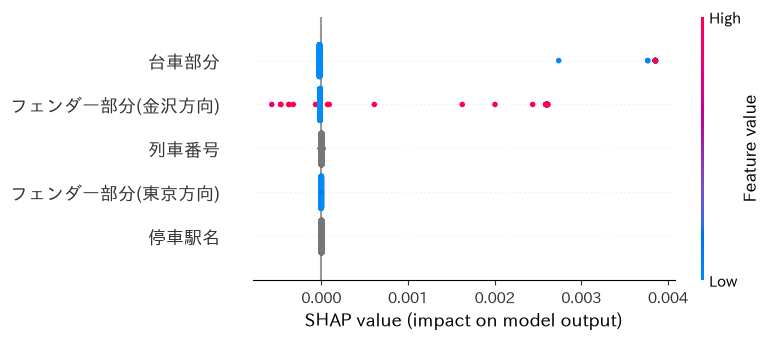

In [ ]:

# 変数別の影響度の可視化
shap.initjs()
# shap.summary_plot(shap_values, X_valid, plot_type="bar", show=False)
shap.summary_plot(shap_values, X_valid, show=False)


# 0番目のデータポイントを再選択
i = 0
single_observation = X_valid.iloc[i:i+1,:]


#print(single_observation)


# Explainerを使って説明を再計算
# single_shap_values = explainer(single_observation)

# waterfallプロットの生成
# shap.waterfall_plot(single_shap_values[0])

## 10.推論、提出

## 提出用データの作成

In [ ]:
# 特徴量の選定
df_test_p = df_test[feature_list].copy()
df_test_p["unit_area"] = np.log1p(df_test_p["unit_area"])



# 予測
y_pred  = np.expm1(model.predict(df_test_p))
y_scores_submit = np.clip(y_pred, 6e6, 1e8)

print(y_scores_submit)

KeyError: "['停車駅名', 'フェンダー部分(東京方向)', '台車部分', 'フェンダー部分(金沢方向)'] not in index"

In [ ]:

#提出用csvの作成
df_scores_submit = pd.DataFrame(y_scores_submit)

# df_submit = pd.concat([df_test["id"], df_scores_submit], axis=1)
# df_scores_submit.index = df_scores_submit.index + 1
df_scores_submit.to_csv("submit.csv", index=True, header=False)




## 誤差要因分析

In [ ]:
# valid予測
y_pred_valid = model.predict(X_valid, num_iteration=model.best_iteration)
# 対数変換を戻す
y_pred_valid = np.expm1(y_pred_valid)

df_eval = X_valid.copy()
df_eval["y_true"] = y_valid
df_eval["y_pred"] = y_pred_valid

# APE計算（0割防止）
df_eval["ape"] = np.abs(df_eval["y_true"] - df_eval["y_pred"]) / np.maximum(df_eval["y_true"], 1e-7)

# 上位ワースト確認
# df_eval.sort_values("ape", ascending=False).head(20)
df_eval["スコア差分"] = df_eval["y_true"] - df_eval["y_pred"]
df_eval["スコア差分"].plot.hist(bins=50, figsize=(10,5))

In [ ]:
# 価格帯ビン作成
df_eval["price_bin"] = pd.qcut(df_eval["y_true"], q=5)

# 価格帯別MAPE
mape_by_bin = df_eval.groupby("price_bin")["ape"].mean() * 100
print("価格帯別のMAPE\n", mape_by_bin)
print()
print("全データのMAPE", df_eval["ape"].mean())
print()


In [ ]:
def compare_distribution(col):
    return pd.DataFrame({
        "train": df_train[col].describe(),
        "valid": X_valid[col].describe()
    })

# compare_distribution("money_rimawari_now")


In [ ]:
# APEが大きい上位10%
threshold = df_eval["ape"].quantile(0.9)
bad_samples = df_eval[df_eval["ape"] >= threshold]

# SHAP値抽出
shap_values_valid = explainer.shap_values(X_valid)
shap_df = pd.DataFrame(
    shap_values_valid,
    columns=X_valid.columns,
    index=X_valid.index
)


# 悪いサンプルのSHAP平均
shap_df.loc[bad_samples.index].abs().mean().sort_values(ascending=False).head(10)


In [ ]:
# shap.force_plot(base_value=explainer.expected_value, shap_values=shap_values, features=X_train)

In [ ]:
def calc_mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / np.maximum(y_true, 1e-7))) * 100


# valid 予測
y_pred_valid = model.predict(X_valid, num_iteration=model.best_iteration)
# 対数変換を戻す
y_pred_valid = np.expm1(y_pred_valid)

# MAPE 出力
valid_mape = calc_mape(y_valid, y_pred_valid)
print(f"VALID MAPE: {valid_mape:.4f}%")


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

df_eval = X_valid.copy()
df_eval["unit_area"] = np.expm1(df_eval["unit_area"])
df_eval["y_true"] = y_valid
df_eval["y_pred"] = y_pred_valid
df_eval["ape"] = np.abs(df_eval["y_true"] - df_eval["y_pred"]) / np.maximum(df_eval["y_true"], 1e-7)

# 上位10%の誤差サンプル抽出
threshold = df_eval["ape"].quantile(0.9)
bad_samples = df_eval[df_eval["ape"] >= threshold]

# 調査対象の特徴量リスト
check_features = [
    "unit_area",
    "post1",
    "floor_plan_code",
    "walk_distance1",
    "walk_distance2",
]

# タグ系カラムを抽出（feature_list に基づく）
tag_features = [col for col in feature_list if col.startswith("tag_")]
check_features.extend(tag_features)

# 1. 数値特徴量の誤差 vs 値域の関係
num_features = ["unit_area", "walk_distance1", "walk_distance2"]
for col in num_features:
    plt.figure(figsize=(8,4))
    sns.scatterplot(data=df_eval, x=col, y="ape", alpha=0.3)
    sns.scatterplot(data=bad_samples, x=col, y="ape", color="red", alpha=0.5)
    plt.title(f"{col} と予測誤差(APE)の関係")
    plt.ylabel("APE")
    plt.xlabel(col)
    plt.show()

# 2. カテゴリ特徴量の誤差分布（箱ひげ図）
cat_features = ["post1", "floor_plan_code"]
for col in cat_features:
    plt.figure(figsize=(10,4))
    sns.boxplot(x=col, y="ape", data=df_eval)
    plt.title(f"{col} ごとの予測誤差(APE)分布")
    plt.xticks(rotation=45)
    plt.show()

# 3. タグ系特徴量の影響（悪いサンプルと全体比較）
for col in tag_features:
    if col not in df_eval.columns:
        continue
    mean_all = df_eval[col].mean()
    mean_bad = bad_samples[col].mean()
    print(f"{col}: 全体平均={mean_all:.3f}, 誤差上位10%平均={mean_bad:.3f}")
